# Chapter 06. 무작위 대조 실험 (RCT) — Difference in Means

## 학습 목표

- 무작위배정(Randomization)과 RCT의 원리를 이해한다
- 평균 처치 효과(ATE) 추정의 수학적 기초를 학습한다
- Difference in Means를 NumPy, SciPy, statsmodels로 구현한다
- OpenAI SDK를 활용한 자동 인과 분석 파이프라인을 구축한다
- LLM이 통계 결과를 자연어로 해석하는 과정을 경험한다

In [19]:
# ============================================================
# 필수 패키지 설치 및 import
# ============================================================
# pip install을 통해 필요한 패키지들을 설치한다.
# OPENAI_API_KEY 환경 변수가 설정되어 있어야 한다.

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Optional, Dict, Any

In [20]:
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager, rc

# 1. OS별 폰트 설정
if platform.system() == 'Windows':
    font_name = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    font_name = 'AppleGothic'
else: # Linux
    font_name = 'NanumGothic'

# 2. matplotlib에 폰트 설정 적용
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False #

In [21]:
# 환경 변수 로드 및 OpenAI 클라이언트 초기화
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [ ]:
# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# CAIS 라이브러리 경로 추가
sys.path.insert(0, os.path.abspath(".."))

print("✓ 모든 패키지 import 완료")

✓ 모든 패키지 import 완료


## 1. RCT와 무작위배정의 원리

**무작위배정(Randomization)**은 인과추론의 가장 강력한 식별 전략이다.

무작위배정이 이루어지면:
- 처치 그룹과 대조 그룹이 **모든 관찰된/관찰되지 않은 특성**에서 평균적으로 동일해진다
- 처치와 결과변수 간의 상관성이 순전히 인과효과가 된다
- **선택 편향(selection bias)**이 제거된다

따라서 **단순 평균 차이**만으로도 인과효과를 추정할 수 있다:

$$\tau = E[Y_i(1) - Y_i(0)] = E[Y_i | D_i = 1] - E[Y_i | D_i = 0]$$

In [22]:
# ============================================================
# RCT 시뮬레이션: 무작위배정으로 ATE 추정
# ============================================================
# 무작위배정이 없는 관찰 데이터와 있는 RCT 데이터를 비교한다.
# 진정한 인과효과는 τ = 10이다.

np.random.seed(42)

n = 1000
true_ate = 10  # 진정한 평균 처치 효과

# 1. 관찰 데이터 (선택 편향 있음)
# 건강도(U)가 높으면 더 많은 치료를 받고, 더 빨리 회복한다.
U_observational = np.random.normal(0, 1, n)  # 관찰되지 않은 혼동변수
D_observational = (U_observational > 0).astype(int)  # 건강도 높으면 치료 선택
Y_observational = 10 * D_observational + 15 * U_observational + np.random.normal(0, 5, n)

# 2. RCT 데이터 (무작위배정)
# 처치를 완전히 무작위로 배정한다.
D_rct = np.random.binomial(1, 0.5, n)  # 동전을 던져서 배정
U_rct = np.random.normal(0, 1, n)  # 처치와 무관하게 독립적인 U
Y_rct = true_ate * D_rct + 5 * U_rct + np.random.normal(0, 5, n)

# 3. ATE 추정
ate_observational = Y_observational[D_observational == 1].mean() - Y_observational[D_observational == 0].mean()
ate_rct = Y_rct[D_rct == 1].mean() - Y_rct[D_rct == 0].mean()

print(f"진정한 ATE: {true_ate:.2f}")
print(f"관찰 데이터 ATE (편향): {ate_observational:.2f} (편향: {ate_observational - true_ate:.2f})")
print(f"RCT 데이터 ATE (무편향): {ate_rct:.2f} (편향: {ate_rct - true_ate:.2f})")
print()
print("→ 무작위배정으로 선택 편향이 제거되어 ATE를 올바르게 추정할 수 있다!")

진정한 ATE: 10.00
관찰 데이터 ATE (편향): 33.00 (편향: 23.00)
RCT 데이터 ATE (무편향): 9.94 (편향: -0.06)

→ 무작위배정으로 선택 편향이 제거되어 ATE를 올바르게 추정할 수 있다!


## 2. Difference in Means 수동 구현

Difference in Means (DiM)은 RCT 데이터를 분석하는 가장 기본적인 방법이다.

**핵심 공식:**

- ATE 추정: $\hat{\tau} = \bar{Y}_1 - \bar{Y}_0$
- 표준오차: $SE = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}$
- t-통계량: $t = \frac{\hat{\tau}}{SE}$
- 95% 신뢰구간: $[\hat{\tau} - 1.96 \times SE, \hat{\tau} + 1.96 \times SE]$

In [24]:
# ============================================================
# Difference in Means 수동 구현 (NumPy + SciPy)
# ============================================================
# 평균, 표준오차, t-검정, 신뢰구간을 모두 수동으로 계산한다.

def estimate_dim_manual(df, treatment_col, outcome_col, alpha=0.05):
    """
    Difference in Means를 수동으로 추정한다.
    
    Parameters:
        df: DataFrame
        treatment_col: 처치 변수명 (binary 0/1)
        outcome_col: 결과 변수명
        alpha: 유의수준 (기본값: 0.05)
    
    Returns:
        dict: effect_estimate, se, t_stat, p_value, ci_lower, ci_upper
    """
    # 처치 그룹과 대조 그룹 분리
    Y_treated = df[df[treatment_col] == 1][outcome_col].values
    Y_control = df[df[treatment_col] == 0][outcome_col].values
    
    n1, n0 = len(Y_treated), len(Y_control)
    
    # 1. 평균 계산
    mean_treated = Y_treated.mean()
    mean_control = Y_control.mean()
    effect = mean_treated - mean_control
    
    # 2. 표본 분산 계산
    var_treated = Y_treated.var(ddof=1)  # ddof=1: 표본 분산
    var_control = Y_control.var(ddof=1)
    
    # 3. 표준오차 계산: SE = sqrt(s1²/n1 + s0²/n0)
    se = np.sqrt(var_treated / n1 + var_control / n0)
    
    # 4. t-통계량 계산
    t_stat = effect / se
    
    # 5. p-값 계산 (양측 검정)
    df_welch = (var_treated/n1 + var_control/n0)**2 / \
               ((var_treated/n1)**2/(n1-1) + (var_control/n0)**2/(n0-1))
    p_value = 2 * stats.t.sf(np.abs(t_stat), df_welch)
    
    # 6. 신뢰구간 계산
    t_crit = stats.t.ppf(1 - alpha/2, df_welch)
    ci_lower = effect - t_crit * se
    ci_upper = effect + t_crit * se
    
    return {
        "effect_estimate": effect,
        "se": se,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "n_treated": n1,
        "n_control": n0,
        "mean_treated": mean_treated,
        "mean_control": mean_control,
    }

# hospital_treatment.csv 데이터 로드
df_hospital = pd.read_csv('./dataset/hospital_treatment.csv')
print(f"Hospital Treatment 데이터 로드: {df_hospital.shape}")
print(df_hospital.head())
print()

# DiM 추정 실행
result = estimate_dim_manual(df_hospital, 'treatment', 'days')

# 결과 출력
print("=== Difference in Means 추정 결과 ===")
print(f"처치 효과: {result['effect_estimate']:.4f} (95% CI: [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}])")
print(f"표준오차: {result['se']:.4f}")
print(f"t-통계량: {result['t_stat']:.4f}")
print(f"p-값: {result['p_value']:.4f}")
print()
print(f"처치군 평균: {result['mean_treated']:.4f} (n={result['n_treated']})")
print(f"대조군 평균: {result['mean_control']:.4f} (n={result['n_control']})")

Hospital Treatment 데이터 로드: (80, 4)
   hospital  treatment   severity  days
0         1          1  29.686618    82
1         1          1  20.050340    57
2         1          1  20.302399    49
3         0          0  10.603118    44
4         0          0   8.332793    15

=== Difference in Means 추정 결과 ===
처치 효과: 14.1533 (95% CI: [6.9147, 21.3919])
표준오차: 3.6023
t-통계량: 3.9289
p-값: 0.0003

처치군 평균: 47.4200 (n=50)
대조군 평균: 33.2667 (n=30)


## 3. statsmodels OLS로 Difference in Means 구현

Difference in Means는 실제로는 **OLS 회귀의 특수한 경우**이다:

$$Y_i = \alpha + \tau D_i + \varepsilon_i$$

여기서:
- $D_i = 1$ (처치), $D_i = 0$ (대조)
- $\hat{\tau}$ = 처치 계수 = 평균 처치 효과
- $\hat{\alpha}$ = 대조군 평균

이를 통해 회귀 표준 도구(t-test, 신뢰구간, 진단)를 활용할 수 있다.

In [25]:
# ============================================================
# statsmodels OLS로 Difference in Means 구현
# ============================================================

def estimate_dim_ols(df, treatment_col, outcome_col):
    """
    statsmodels OLS로 Difference in Means를 추정한다.
    처치 계수가 ATE가 된다.
    
    Parameters:
        df: DataFrame
        treatment_col: 처치 변수명
        outcome_col: 결과 변수명
    
    Returns:
        dict: OLS 결과 (계수, 표준오차, t-값, p-값, 신뢰구간)
    """
    # OLS 모델 구성: Y = α + τ*D
    X = df[[treatment_col]].copy()
    X = sm.add_constant(X)  # 상수항 추가
    y = df[outcome_col].copy()
    
    # OLS 적합
    model = sm.OLS(y, X).fit()
    
    # 결과 추출
    params = model.params
    bse = model.bse
    pvalues = model.pvalues
    conf_int = model.conf_int()
    
    return {
        "effect_estimate": params[treatment_col],
        "se": bse[treatment_col],
        "t_stat": model.tvalues[treatment_col],
        "p_value": pvalues[treatment_col],
        "ci_lower": conf_int.loc[treatment_col, 0],
        "ci_upper": conf_int.loc[treatment_col, 1],
        "control_mean": params['const'],
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "nobs": model.nobs,
        "model": model  # 전체 모델 객체
    }

# OLS 추정 실행
result_ols = estimate_dim_ols(df_hospital, 'treatment', 'days')

# 결과 출력
print("=== OLS 기반 Difference in Means ===")
print(f"처치 효과 (τ̂): {result_ols['effect_estimate']:.4f}")
print(f"표준오차: {result_ols['se']:.4f}")
print(f"95% 신뢰구간: [{result_ols['ci_lower']:.4f}, {result_ols['ci_upper']:.4f}]")
print(f"t-통계량: {result_ols['t_stat']:.4f}")
print(f"p-값: {result_ols['p_value']:.6f}")
print()
print(f"대조군 평균 (α̂): {result_ols['control_mean']:.4f}")
print(f"R²: {result_ols['r_squared']:.4f}")
print(f"관측치 수: {result_ols['nobs']}")
print()

# 전체 모델 요약 출력
print(result_ols['model'].summary())

=== OLS 기반 Difference in Means ===
처치 효과 (τ̂): 14.1533
표준오차: 3.3668
95% 신뢰구간: [7.4505, 20.8561]
t-통계량: 4.2038
p-값: 0.000069

대조군 평균 (α̂): 33.2667
R²: 0.1847
관측치 수: 80.0

                            OLS Regression Results                            
Dep. Variable:                   days   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     17.67
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           6.93e-05
Time:                        22:29:23   Log-Likelihood:                -326.87
No. Observations:                  80   AIC:                             657.7
Df Residuals:                      78   BIC:                             662.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err        

## 4. 진단(Diagnostics) — 그룹 통계량과 분산 동질성

DiM 추정 전에 다음을 확인해야 한다:

1. **그룹 균형성**: 무작위배정이 제대로 이루어졌는가? (처치/대조군의 기초 특성이 유사한가?)
2. **분산 동질성**: 두 그룹의 분산이 같은가? (Welch t-test vs Student t-test)
3. **표본 크기**: 두 그룹의 표본 크기가 충분한가?

In [26]:
# ============================================================
# Diagnostics: 그룹 통계량과 분산 동질성 검정
# ============================================================

def run_dim_diagnostics(df, treatment_col, outcome_col):
    """
    DiM 분석 전 기본 진단을 수행한다.
    
    Parameters:
        df: DataFrame
        treatment_col: 처치 변수명
        outcome_col: 결과 변수명
    
    Returns:
        dict: 그룹별 통계량, 분산 비율, 균형성 평가
    """
    # 그룹별 데이터 분리
    Y_treated = df[df[treatment_col] == 1][outcome_col]
    Y_control = df[df[treatment_col] == 0][outcome_col]
    
    # 그룹별 통계량
    treated_stats = {
        "n": len(Y_treated),
        "mean": Y_treated.mean(),
        "std": Y_treated.std(),
        "min": Y_treated.min(),
        "max": Y_treated.max(),
    }
    control_stats = {
        "n": len(Y_control),
        "mean": Y_control.mean(),
        "std": Y_control.std(),
        "min": Y_control.min(),
        "max": Y_control.max(),
    }
    
    # 분산 비율 (Variance Ratio Test)
    var_ratio = treated_stats['std']**2 / control_stats['std']**2
    
    # Levene 검정 (분산 동질성)
    from scipy.stats import levene
    levene_stat, levene_p = levene(Y_treated, Y_control)
    
    # 균형성 평가
    balance_issue = abs(var_ratio - 1) > 0.5  # 분산 비율이 0.5~2 범위 밖이면 문제
    
    return {
        "treated_group": treated_stats,
        "control_group": control_stats,
        "variance_ratio": var_ratio,
        "levene_stat": levene_stat,
        "levene_p": levene_p,
        "balance_concern": balance_issue,
        "Y_treated": Y_treated,
        "Y_control": Y_control,
    }

# 진단 실행
diagnostics = run_dim_diagnostics(df_hospital, 'treatment', 'days')

print("=== Diagnostics: 그룹 통계량 ===")
print()
print("[처치 그룹 (treatment=1)]")
for key, val in diagnostics['treated_group'].items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

print()
print("[대조 그룹 (treatment=0)]")
for key, val in diagnostics['control_group'].items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

print()
print("=== 분산 동질성 검정 ===")
print(f"분산 비율 (σ₁²/σ₀²): {diagnostics['variance_ratio']:.4f}")
print(f"Levene 검정 통계량: {diagnostics['levene_stat']:.4f}")
print(f"Levene p-값: {diagnostics['levene_p']:.4f}")
print()
if diagnostics['levene_p'] > 0.05:
    print("→ 분산이 동질적이다 (Welch's t-test 또는 Student t-test 모두 사용 가능)")
else:
    print("→ 분산이 이질적이다 (Welch's t-test 권장)")

=== Diagnostics: 그룹 통계량 ===

[처치 그룹 (treatment=1)]
  n: 50
  mean: 47.4200
  std: 12.9364
  min: 14
  max: 82

[대조 그룹 (treatment=0)]
  n: 30
  mean: 33.2667
  std: 16.9968
  min: 0
  max: 67

=== 분산 동질성 검정 ===
분산 비율 (σ₁²/σ₀²): 0.5793
Levene 검정 통계량: 4.5791
Levene p-값: 0.0355

→ 분산이 이질적이다 (Welch's t-test 권장)


/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_73032/233137169.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hospital_copy, x='group', y='days', ax=axes[0], palette='Set2')


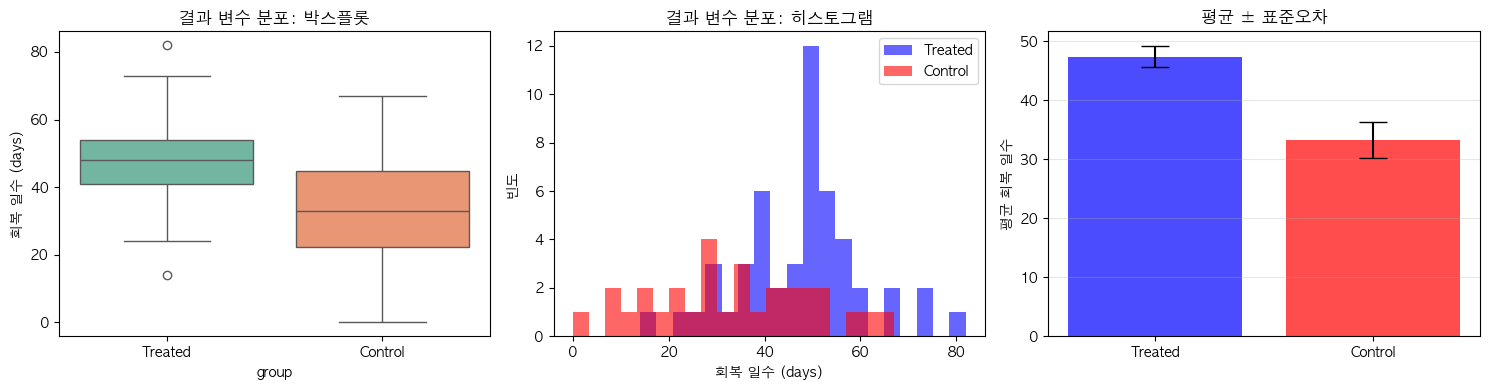

처치 효과 = 14.1533


In [27]:
# ============================================================
# Diagnostics 시각화: 분포 비교
# ============================================================
# 박스플롯과 히스토그램으로 두 그룹의 분포를 시각화한다.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 박스플롯
df_hospital_copy = df_hospital.copy()
df_hospital_copy['group'] = df_hospital_copy['treatment'].map({1: 'Treated', 0: 'Control'})
sns.boxplot(data=df_hospital_copy, x='group', y='days', ax=axes[0], palette='Set2')
axes[0].set_title('결과 변수 분포: 박스플롯')
axes[0].set_ylabel('회복 일수 (days)')

# 히스토그램 (Treated)
axes[1].hist(diagnostics['Y_treated'], bins=20, alpha=0.6, label='Treated', color='blue')
axes[1].hist(diagnostics['Y_control'], bins=20, alpha=0.6, label='Control', color='red')
axes[1].set_xlabel('회복 일수 (days)')
axes[1].set_ylabel('빈도')
axes[1].set_title('결과 변수 분포: 히스토그램')
axes[1].legend()

# 평균 ± 표준오차
groups = ['Treated', 'Control']
means = [diagnostics['treated_group']['mean'], diagnostics['control_group']['mean']]
stds = [diagnostics['treated_group']['std'], diagnostics['control_group']['std']]
ns = [diagnostics['treated_group']['n'], diagnostics['control_group']['n']]
ses = [s / np.sqrt(n) for s, n in zip(stds, ns)]

axes[2].bar(groups, means, yerr=ses, capsize=10, alpha=0.7, color=['blue', 'red'])
axes[2].set_ylabel('평균 회복 일수')
axes[2].set_title('평균 ± 표준오차')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"처치 효과 = {diagnostics['treated_group']['mean'] - diagnostics['control_group']['mean']:.4f}")

## 5. OpenAI SDK로 자동 인과 분석 파이프라인

이제 LLM을 활용하여 **변수 식별 → DiM 실행 → 결과 해석**을 자동으로 수행하는 파이프라인을 구축한다.

이 파이프라인의 장점:
1. **자동 변수 식별**: 사용자가 "어떤 변수가 처치인가?"라고 묻기만 하면, LLM이 분석해준다
2. **구조화된 출력**: Pydantic 모델로 LLM 응답을 검증한다
3. **자연어 해석**: 통계 결과를 일반인도 이해할 수 있도록 설명한다

In [28]:
# ============================================================
# Pydantic 모델 정의: 구조화된 LLM 응답
# ============================================================
# OpenAI SDK의 Structured Outputs를 사용하여 LLM 응답을 검증한다.

class CausalVariable(BaseModel):
    """인과추론을 위한 변수 정의이다."""
    variable_name: str = Field(description="컬럼명 (예: treatment, days)")
    variable_type: str = Field(description="변수 타입 (treatment/outcome/covariate)")
    description: str = Field(description="변수 설명 (한국어)")
    validation: str = Field(description="데이터 검증 결과 (예: binary, continuous)")

class CausalVariables(BaseModel):
    """데이터셋의 인과 변수들이다."""
    treatment: CausalVariable = Field(description="처치 변수")
    outcome: CausalVariable = Field(description="결과 변수")
    covariates: List[CausalVariable] = Field(description="공변량들 (선택사항)")
    reasoning: str = Field(description="변수 선택의 근거 (한국어, 2~3문장)")

class DiMResult(BaseModel):
    """Difference in Means 분석 결과이다."""
    effect_estimate: float = Field(description="평균 처치 효과")
    se: float = Field(description="표준오차")
    p_value: float = Field(description="p-값 (양측 검정)")
    ci_lower: float = Field(description="95% 신뢰구간 하한")
    ci_upper: float = Field(description="95% 신뢰구간 상한")
    significant: bool = Field(description="유의하는가? (p < 0.05)")
    n_treated: int = Field(description="처치군 표본 수")
    n_control: int = Field(description="대조군 표본 수")
    interpretation: str = Field(description="결과 해석 (한국어, 2~3문장)")

print("✓ Pydantic 모델 정의 완료")

✓ Pydantic 모델 정의 완료


In [29]:
# ============================================================
# Step 1: LLM 기반 변수 식별
# ============================================================
# 사용자의 자연어 질문으로부터 처치/결과 변수를 식별한다.

def identify_causal_variables(df, user_query):
    """
    LLM을 사용하여 데이터셋에서 처치/결과 변수를 식별한다.
    
    Parameters:
        df: DataFrame
        user_query: 사용자의 인과추론 질문 (한국어)
    
    Returns:
        CausalVariables: 식별된 변수들 (구조화된 형식)
    """
    # 데이터셋 정보 구성
    dataset_info = {
        "columns": df.columns.tolist(),
        "shape": df.shape,
        "dtypes": {col: str(df[col].dtype) for col in df.columns},
        "sample_data": df.head(3).to_dict('records'),
        "descriptive_stats": df.describe().to_dict(),
    }
    
    system_prompt = """너는 인과추론 전문가이다.
사용자의 질문과 데이터셋 정보를 바탕으로, 인과추론을 수행하기 위한 처치/결과 변수를 식별한다.
항상 JSON 형식의 구조화된 응답을 반환한다.
"""
    
    user_message = f"""질문: {user_query}

데이터셋 정보:
{json.dumps(dataset_info, ensure_ascii=False, indent=2)}

이 질문에 대해 다음을 판단해주세요:
1. 처치 변수는 무엇인가?
2. 결과 변수는 무엇인가?
3. 공변량이 있는가?
4. 선택 근거는?
"""
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message}
        ],
        response_format=CausalVariables
    )
    
    return response.choices[0].message.parsed

# 테스트: hospital_treatment.csv
query = "입원 환자에게 새로운 치료법(treatment)이 회복 일수(days)에 미치는 영향을 분석하고 싶습니다."
causal_vars = identify_causal_variables(df_hospital, query)

print("=== Step 1: LLM 기반 변수 식별 ===")
print(f"질문: {query}")
print(f"처치: {causal_vars.treatment.variable_name}")
print(f"  설명: {causal_vars.treatment.description}")
print(f"  타입: {causal_vars.treatment.validation}")
print(f"결과: {causal_vars.outcome.variable_name}")
print(f"  설명: {causal_vars.outcome.description}")
print(f"  타입: {causal_vars.outcome.validation}")
print(f"근거: {causal_vars.reasoning}")

=== Step 1: LLM 기반 변수 식별 ===
질문: 입원 환자에게 새로운 치료법(treatment)이 회복 일수(days)에 미치는 영향을 분석하고 싶습니다.
처치: treatment
  설명: 입원 환자에게 적용된 새로운 치료법
  타입: binary
결과: days
  설명: 회복에 소요된 일수
  타입: continuous
근거: 입원 환자에게 새로운 치료법의 효과를 분석하기 위해서는 치료법(treatment)과 회복 일수(days)의 관계를 연구할 필요가 있으며, 이 과정에서 환자의 질병 중증도(severity)가 결과에 영향을 미칠 수 있으므로 공변량으로 고려해야 합니다.


In [30]:
# ============================================================
# Step 2 & 3: DiM 실행 + 자연어 해석
# ============================================================
# 식별된 변수로 DiM을 실행하고, LLM이 결과를 해석한다.

def analyze_and_interpret_dim(df, causal_vars):
    """
    DiM을 실행하고, LLM이 결과를 자연어로 해석한다.
    
    Parameters:
        df: DataFrame
        causal_vars: CausalVariables (식별된 변수들)
    
    Returns:
        DiMResult: 추정 결과 + LLM 해석
    """
    treatment_col = causal_vars.treatment.variable_name
    outcome_col = causal_vars.outcome.variable_name
    
    # DiM 추정 실행
    dim_result = estimate_dim_manual(df, treatment_col, outcome_col)
    
    # 결과를 LLM에 전달해 자연어로 해석하게 한다
    result_json = json.dumps({
        "effect_estimate": dim_result['effect_estimate'],
        "se": dim_result['se'],
        "t_stat": dim_result['t_stat'],
        "p_value": dim_result['p_value'],
        "ci_lower": dim_result['ci_lower'],
        "ci_upper": dim_result['ci_upper'],
        "mean_treated": dim_result['mean_treated'],
        "mean_control": dim_result['mean_control'],
        "n_treated": dim_result['n_treated'],
        "n_control": dim_result['n_control'],
    }, ensure_ascii=False)
    
    system_prompt = """너는 통계 분석 결과를 일반인도 이해할 수 있도록 해석하는 전문가이다.
Difference in Means 분석 결과를 받으면, 그 의미를 2~3문장으로 쉽게 설명한다.
전문 용어를 최소화하고, 실질적 의미에 초점을 맞춘다."""
    
    user_message = f"""Difference in Means 분석 결과를 해석해주세요.

처치 변수: {treatment_col}
결과 변수: {outcome_col}

분석 결과:
{result_json}

이 결과를 쉬운 한국어로 2~3문장으로 해석해주세요.
(예: "처치는 결과 변수를 평균 X만큼 증가시켰고, 이는 통계적으로 유의하다...")"""
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message}
        ],
        response_format=DiMResult
    )
    
    dim_model_result = response.choices[0].message.parsed
    return dim_model_result

# 파이프라인 실행
dim_result = analyze_and_interpret_dim(df_hospital, causal_vars)

print("\n=== Step 2 & 3: DiM 실행 + LLM 해석 ===")
print(f"처치 효과: {dim_result.effect_estimate:.4f}")
print(f"표준오차: {dim_result.se:.4f}")
print(f"95% 신뢰구간: [{dim_result.ci_lower:.4f}, {dim_result.ci_upper:.4f}]")
print(f"p-값: {dim_result.p_value:.6f}")
print(f"유의성: {'유의' if dim_result.significant else '유의하지 않음'} (α=0.05)")
print(f"표본 크기: 처치군 {dim_result.n_treated}, 대조군 {dim_result.n_control}")
print("[LLM 해석]")
print(dim_result.interpretation)


=== Step 2 & 3: DiM 실행 + LLM 해석 ===
처치 효과: 14.1533
표준오차: 3.6023
95% 신뢰구간: [6.9147, 21.3919]
p-값: 0.000267
유의성: 유의 (α=0.05)
표본 크기: 처치군 50, 대조군 30
[LLM 해석]
처치는 결과 변수인 'days'를 평균적으로 약 14.15일 증가시켰으며, 이는 통계적으로 유의합니다. 즉, 치료를 받은 그룹이 치료를 받지 않은 그룹보다 평균적으로 많은 날수를 기록했습니다.


## 6. 두 번째 데이터셋: collections_email.csv

이제 다른 데이터셋에서도 파이프라인을 시도한다.

**collections_email.csv**: 채권 추심 이메일 실험
- `email`: 특정 이메일 발송 여부 (처치)
- `payments`: 결제 금액 (결과)
- 다른 변수들: `opened`, `agreement`, `credit_limit`, `risk_score` (배경 정보)

In [31]:
# ============================================================
# collections_email.csv 데이터 로드 및 파이프라인 실행
# ============================================================
# 동일한 파이프라인을 새로운 데이터셋에 적용한다.

df_email = pd.read_csv('./dataset/collections_email.csv')
print(f"Collections Email 데이터 로드: {df_email.shape}")
print(df_email.head())
print()
print(df_email.describe())
print()

# 파이프라인 실행
query_email = "특정 이메일(email)이 채권자의 결제 금액(payments)에 미치는 효과를 분석하고 싶습니다."
causal_vars_email = identify_causal_variables(df_email, query_email)

print("=== collections_email.csv 변수 식별 ===")
print(f"처치: {causal_vars_email.treatment.variable_name}")
print(f"결과: {causal_vars_email.outcome.variable_name}")
print(f"근거: {causal_vars_email.reasoning}")
print()

# DiM 분석
dim_result_email = analyze_and_interpret_dim(df_email, causal_vars_email)

print("=== DiM 분석 결과 ===")
print(f"처치 효과: {dim_result_email.effect_estimate:.4f}")
print(f"95% 신뢰구간: [{dim_result_email.ci_lower:.4f}, {dim_result_email.ci_upper:.4f}]")
print(f"p-값: {dim_result_email.p_value:.6f}")
print(f"유의성: {'유의' if dim_result_email.significant else '유의하지 않음'}")
print(f"표본: 처치 {dim_result_email.n_treated}, 대조 {dim_result_email.n_control}")
print("[LLM 해석]")
print(dim_result_email.interpretation)

Collections Email 데이터 로드: (5000, 6)
   payments  email  opened  agreement  credit_limit  risk_score
0       740      1     1.0        0.0   2348.495260    0.666752
1       580      1     1.0        1.0    334.111969    0.207395
2       600      1     1.0        1.0   1360.660722    0.550479
3       770      0     0.0        0.0   1531.828576    0.560488
4       660      0     0.0        0.0    979.855647    0.455140

          payments        email       opened    agreement  credit_limit  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean    669.672000     0.490800     0.273400     0.160800   1194.845188   
std     103.970065     0.499965     0.445749     0.367383    480.978996   
min     330.000000     0.000000     0.000000     0.000000    193.695573   
25%     600.000000     0.000000     0.000000     0.000000    843.049867   
50%     670.000000     0.000000     0.000000     0.000000   1127.640297   
75%     730.000000     1.000000     1.000000     0.000